In [1]:
import pandas as pd

In [4]:
df = pd.read_csv("../TeamSeasons_2025.csv")
teams = pd.read_csv("/Users/andrewgrowney/Data/kaggle/marchmadness-2025/MTeams.csv")

In [13]:
sweet_sixteen_teams = [
    "Auburn", "Michigan",  "Michigan St", "Mississippi", "Texas Tech", 
    "Alabama", "Arizona", "Duke", "Maryland", "Arkansas", "BYU",
    "Florida", "Houston", "Purdue", "Tennessee", "Kentucky"]

S16_IDS = teams[teams["TeamName"].isin(sweet_sixteen_teams)]["TeamID"].values

In [14]:
teams[teams["TeamID"].isin(S16_IDS)]

,TeamID,TeamName,FirstD1Season,LastD1Season
3,1104,Alabama,1985,2025
11,1112,Arizona,1985,2025
15,1116,Arkansas,1985,2025
19,1120,Auburn,1985,2025
39,1140,BYU,1985,2025
80,1181,Duke,1985,2025
95,1196,Florida,1985,2025
121,1222,Houston,1985,2025
145,1246,Kentucky,1985,2025
167,1268,Maryland,1985,2025


In [20]:
CUR_S16 = df[(df["Season"] == 2025) & (df["TeamID"].isin(S16_IDS))]

In [22]:
FEATURE_COLUMNS = ["Points_mean","Poss_mean","OE_mean","DE_mean","NE_mean","FGM_mean","FGA_mean","FGM3_mean","FGA3_mean","FTM_mean","FTA_mean","OR_mean","DR_mean","Ast_mean","TO_mean","Stl_mean","Blk_mean","Fouls_mean","FG%_mean","FG3%_mean", "EFG%_mean", "FT%_mean","OppPoints_mean","OppFGM_mean","OppFGA_mean","OppFGM3_mean","OppFGA3_mean","OppFTM_mean","OppFTA_mean","OppOR_mean","OppDR_mean","OppAst_mean","OppTO_mean","OppStl_mean","OppBlk_mean","OppFouls_mean","OppFG%_mean","OppFG3%_mean", "OppEFG%_mean", "OppFT%_mean","AdjOE_mean","AdjDE_mean","AdjNE_mean","Points_stdev","Poss_stdev","OE_stdev","DE_stdev","NE_stdev","FGM_stdev","FGA_stdev","FGM3_stdev","FGA3_stdev","FTM_stdev","FTA_stdev","OR_stdev","DR_stdev","Ast_stdev","TO_stdev","Stl_stdev","Blk_stdev","Fouls_stdev","FG%_stdev","FG3%_stdev","EFG%_stdev","FT%_stdev","OppPoints_stdev","OppFGM_stdev","OppFGA_stdev","OppFGM3_stdev","OppFGA3_stdev","OppFTM_stdev","OppFTA_stdev","OppOR_stdev","OppDR_stdev","OppAst_stdev","OppTO_stdev","OppStl_stdev","OppBlk_stdev","OppFouls_stdev","OppFG%_stdev","OppFG3%_stdev","OppEFG%_stdev","OppFT%_stdev","AdjOE_stdev","AdjDE_stdev","AdjNE_stdev","Q1_WinPct","Q2_WinPct","Q3_WinPct","Q4_WinPct","WinPct","SOS","SOV","Seed", "ExitRound"]
NUMERIC_FEATURES = FEATURE_COLUMNS[:-1]

In [19]:
PREV_S16 = df[df["ExitRound"].isin(["Sweet Sixteen", "Elite Eight", "Final Four", "Championship", "Champion"])]

In [24]:
# Data Cleaning
CUR_S16["Q1_WinPct"] = CUR_S16["Q1_WinPct"].fillna(0)
CUR_S16["Q2_WinPct"] = CUR_S16["Q2_WinPct"].fillna(0)
CUR_S16["Q3_WinPct"] = CUR_S16["Q3_WinPct"].fillna(0)
CUR_S16["Q4_WinPct"] = CUR_S16["Q4_WinPct"].fillna(0)

PREV_S16["Q1_WinPct"] = PREV_S16["Q1_WinPct"].fillna(0)
PREV_S16["Q2_WinPct"] = PREV_S16["Q2_WinPct"].fillna(0)
PREV_S16["Q3_WinPct"] = PREV_S16["Q3_WinPct"].fillna(0)
PREV_S16["Q4_WinPct"] = PREV_S16["Q4_WinPct"].fillna(0)

/var/folders/7y/1jp5fzbs05q03xszr7zmwvqw0000gn/T/ipykernel_18046/3719498055.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  CUR_S16["Q1_WinPct"] = CUR_S16["Q1_WinPct"].fillna(0)
/var/folders/7y/1jp5fzbs05q03xszr7zmwvqw0000gn/T/ipykernel_18046/3719498055.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  CUR_S16["Q2_WinPct"] = CUR_S16["Q2_WinPct"].fillna(0)
/var/folders/7y/1jp5fzbs05q03xszr7zmwvqw0000gn/T/ipykernel_18046/3719498055.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of 

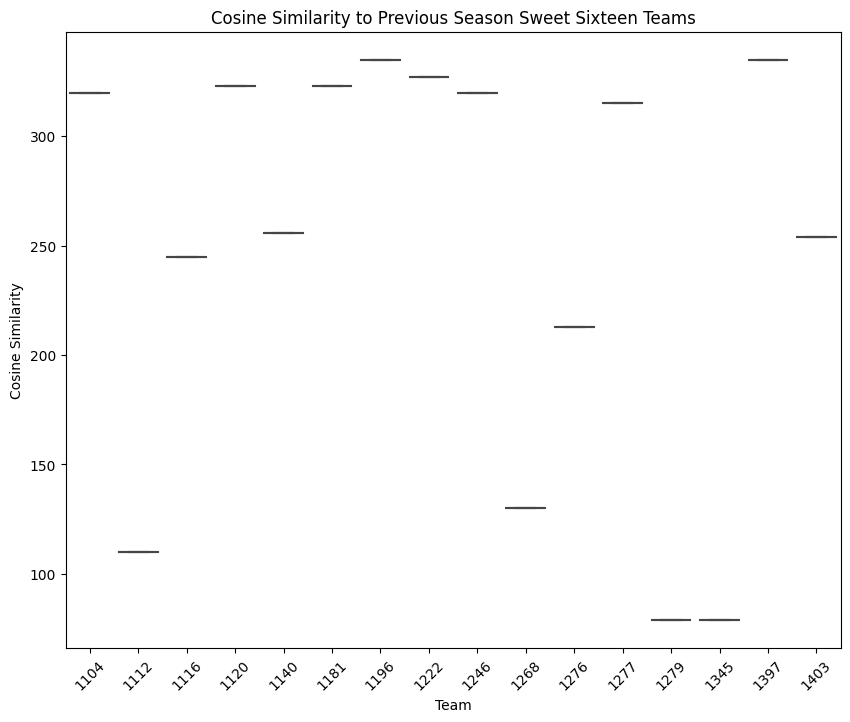

In [27]:
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics.pairwise import cosine_similarity
import seaborn as sns

import matplotlib.pyplot as plt

# Select the feature columns for scaling
features = FEATURE_COLUMNS

# Initialize the MinMaxScaler
scaler = MinMaxScaler()

# Scale the data
PREV_S16_scaled = scaler.fit_transform(PREV_S16[NUMERIC_FEATURES])
CUR_S16_scaled = scaler.transform(CUR_S16[NUMERIC_FEATURES])

# Compute the cosine similarity
cosine_sim = cosine_similarity(PREV_S16_scaled, CUR_S16_scaled)

# Create a grouped boxplot for each current teams to the exit rounds of the prev season teams
plt.figure(figsize=(10, 8))
sns.boxplot(x=CUR_S16["TeamID"], y=cosine_sim.argmax(axis=0))
plt.title("Cosine Similarity to Previous Season Sweet Sixteen Teams")
plt.ylabel("Cosine Similarity")
plt.xlabel("Team")
plt.xticks(rotation=45)
plt.show()